**Objective II - Selecting best model architecture**

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
with open("../src/experiments/results/models_performance.json", "r") as file:
    data = json.load(file)

models = []
language_scores = defaultdict(list)

for model, results in data.items():
    total_model_score = 0
    for language, scores in results.items():
        language_scores[language].append(round(scores["val_f1"], 3))
        total_model_score += round(scores["val_f1"], 3)
    print("Model: {}".format(model))
    print("Avg. Score: {}".format(total_model_score / 6))
    print()
    models.append(model)

Model: BERT
Avg. Score: 0.8873333333333333

Model: BERT-CRF
Avg. Score: 0.9

Model: BERT-Bilstm
Avg. Score: 0.7978333333333333

Model: BERT-Bilstm-CRF
Avg. Score: 0.8805000000000001



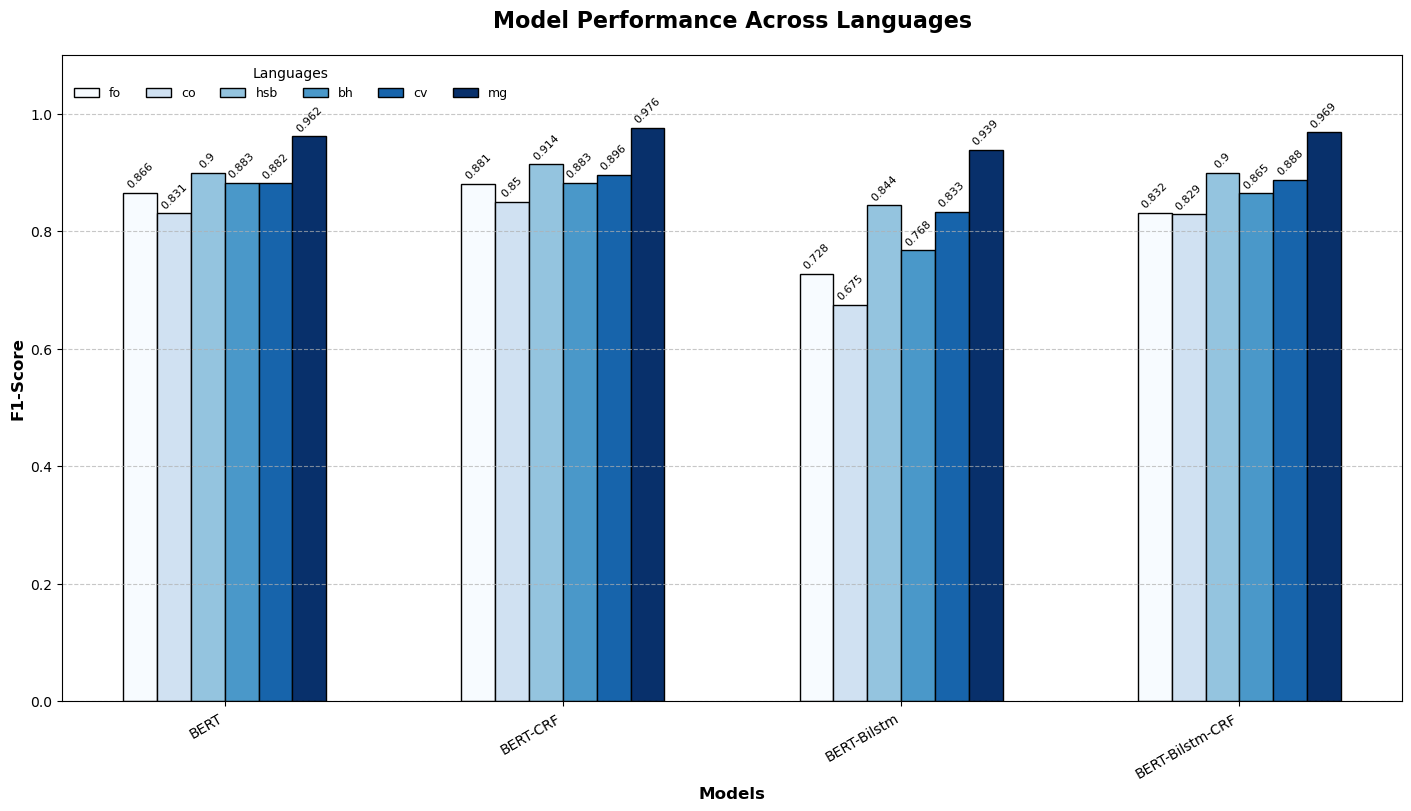

In [3]:
x = np.arange(len(models))
fig, ax = plt.subplots(layout="constrained", figsize=(14, 8))

width = 0.1
multiplier = -2

colors = plt.get_cmap("Blues", len(language_scores))

for idx, (language, scores) in enumerate(language_scores.items()):
    offset = width * multiplier
    rects = ax.bar(
        x + offset,
        scores,
        width,
        label=language,
        color=colors(idx),
        edgecolor='black'
    )
    ax.bar_label(rects, padding=2, fontsize=8, rotation=45)
    multiplier += 1

ax.set_ylabel("F1-Score", fontsize=12, weight="bold")
ax.set_xlabel("Models", fontsize=12, weight="bold")
ax.set_title("Model Performance Across Languages", fontsize=16, weight="bold", pad=20)
ax.set_xticks(x + width / 2, labels=models, fontsize=10, rotation=30, ha="right")
ax.set_ylim(0, 1.1)

ax.grid(axis="y", linestyle="--", alpha=0.7)

ax.legend(
    title="Languages",
    title_fontsize=10,
    fontsize=9,
    loc="upper left",
    ncols = 6,
    frameon=False
)

plt.show()

**Objective III - training baseline model**

In [4]:
with open("../src/experiments/results/baseline_model_performance.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
language_scores = {}

total_model_score = 0
for language, scores in data.items():
    language_scores[language] = round(scores["val_f1"], 3)
    total_model_score += round(scores["val_f1"], 3)

    print(f"Lang: {language}, Val-F1: {scores['val_f1']:.5f}")

print("\nModel: {}".format(model))
print("Avg. Score: {}".format(total_model_score / 6))
print()

Lang: fo, Val-F1: 0.89083
Lang: co, Val-F1: 0.85126
Lang: hsb, Val-F1: 0.91975
Lang: bh, Val-F1: 0.89430
Lang: cv, Val-F1: 0.89381
Lang: mg, Val-F1: 0.97265

Model: BERT-CRF
Avg. Score: 0.9038333333333334



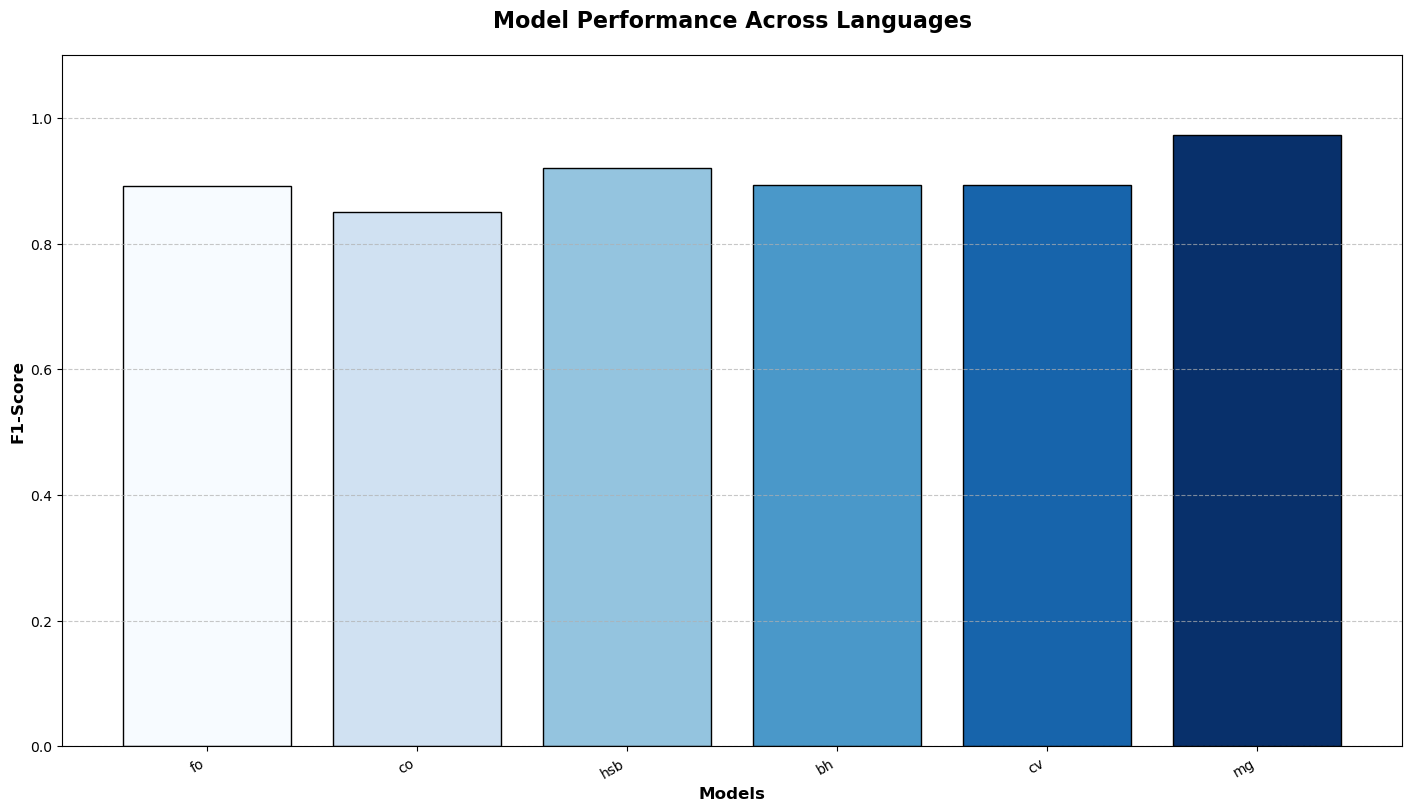

In [5]:
fig, ax = plt.subplots(layout="constrained", figsize=(14, 8))

langs = list(language_scores.keys())
scores = list(language_scores.values())

x = np.arange(len(langs))

colors = plt.get_cmap("Blues", len(language_scores))
norm = plt.Normalize(min(x), max(x))

bars = ax.bar(langs, scores, edgecolor='black')

ax.set_ylabel("F1-Score", fontsize=12, weight="bold")
ax.set_xlabel("Models", fontsize=12, weight="bold")
ax.set_title("Model Performance Across Languages", fontsize=16, weight="bold", pad=20)
ax.set_xticks(np.arange(len(langs)), labels=langs, fontsize=10, rotation=30, ha="right")
ax.set_ylim(0, 1.1)

ax.grid(axis="y", linestyle="--", alpha=0.7)

for bar, value in zip(bars, x):
    bar.set_color(colors(norm(value)))
    bar.set_edgecolor("black")

plt.show()

**Objective IV - Cross-lingual transfer learning**

In [6]:
with open("../src/experiments/results/transfer_learning_performance1.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
language_scores = {}

total_model_score = 0
for language, scores in data.items():
    language_scores[language] = round(scores["val_f1"], 3)
    total_model_score += round(scores["val_f1"], 3)

    print(f"Lang: {language}, Val-F1: {scores['val_f1']:.5f}")

print("\nModel: {}".format(model))
print("Avg. Score: {}".format(total_model_score / 6))
print()

Lang: fo_is, Val-F1: 0.90747
Lang: co_it, Val-F1: 0.87844
Lang: hsb_pl, Val-F1: 0.93179
Lang: bh_hi, Val-F1: 0.89956
Lang: cv_tt, Val-F1: 0.90828
Lang: mg_id, Val-F1: 0.97825

Model: BERT-CRF
Avg. Score: 0.9171666666666667



In [7]:
with open("../src/experiments/results/transfer_learning_performance2.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
language_scores = {}

total_model_score = 0
for language, scores in data.items():
    language_scores[language] = round(scores["val_f1"], 3)
    total_model_score += round(scores["val_f1"], 3)

    print(f"Lang: {language}, Val-F1: {scores['val_f1']:.5f}")

print("\nModel: {}".format(model))
print("Avg. Score: {}".format(total_model_score / 6))
print()

Lang: fo_is, Val-F1: 0.91330
Lang: co_it, Val-F1: 0.88750
Lang: hsb_pl, Val-F1: 0.92570
Lang: bh_hi, Val-F1: 0.89696
Lang: cv_tt, Val-F1: 0.91768
Lang: mg_id, Val-F1: 0.97865

Model: BERT-CRF
Avg. Score: 0.92



In [14]:
with open("../src/experiments/results/transfer_learning_performance5.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
language_scores = {}

total_model_score = 0
for language, scores in data.items():
    language_scores[language] = round(scores["val_f1"], 3)
    total_model_score += round(scores["val_f1"], 3)

    print(f"Lang: {language}, Val-F1: {scores['val_f1']:.5f}")

print("\nModel: {}".format(model))
print("Avg. Score: {}".format(total_model_score / 6))
print()

Lang: fo_is, Val-F1: 0.92483
Lang: co_it, Val-F1: 0.89218
Lang: hsb_pl, Val-F1: 0.93897
Lang: bh_hi, Val-F1: 0.90387
Lang: cv_tt, Val-F1: 0.92438
Lang: mg_id, Val-F1: 0.98567

Model: BERT-CRF
Avg. Score: 0.9283333333333333

